In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [3]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [4]:
tmp = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits', columns=['SV1_DESI_TARGET', 'TARGETS', 'coadd_type']))
mask = (tmp['SV1_DESI_TARGET'] & 2**0 > 0) & (tmp['TARGETS']=='QSO+LRG') & (tmp['coadd_type']=='cumulative')
idx = np.where(mask)[0]
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/denali/testdenali/All/alltiles_Allzinfo.fits', rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

52268
52023


In [5]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

FIBERSTATUS 43371 8897 0.17021887196755184
No data 43368 3 6.917064397869545e-05


In [6]:
# Require a minimum depth for the deep coadd
min_depth = 2000.
mask = zbest['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))

Min depth 36843 6525 0.8495434421693414
36843


In [7]:
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

36843
36704


In [8]:
# Remove duplicates
_, idx = np.unique(zbest['TARGETID'], return_index=True)
zbest = zbest[idx]
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

36704
36704


In [9]:
# Ting-Wen's quality cuts
mask = zbest['ZWARN']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
mask &= zbest['Z']<1.4
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
mask &= zbest['DELTACHI2']>20
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(zbest))

Quality cuts 36339 365 0.9900555797733217
Quality cuts 35930 774 0.9789123801220575
Quality cuts 35658 1046 0.9715017436791631
35658


__Add MEDIUM and WISE masks and require NOBS>=2__

In [10]:
maskbits = [1, 8, 11, 12, 13]
min_nobs = 2

mask_clean = np.ones(len(zbest), dtype=bool)
for bit in maskbits:
    mask_clean &= (zbest['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))

# mask_clean &= (zbest['NOBS_G']>=min_nobs) & (zbest['NOBS_R']>=min_nobs) & (zbest['NOBS_Z']>=min_nobs)
# print(np.sum(~mask_clean)/len(mask_clean))

zbest = zbest[mask_clean]

0.07431712378708845


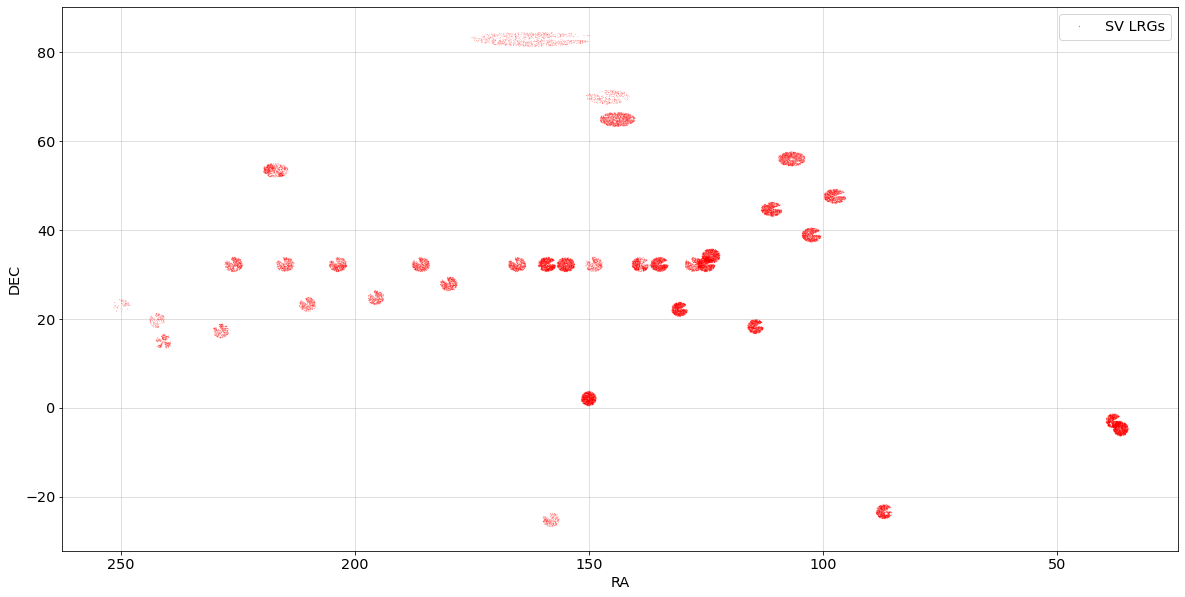

In [11]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [12]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']) - 3.214 * zbest['EBV']
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']) - 2.165 * zbest['EBV']
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']) - 1.211 * zbest['EBV']
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']) - 0.184 * zbest['EBV']
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']) - 0.113 * zbest['EBV']
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']) - 3.214 * zbest['EBV']
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']) - 2.165 * zbest['EBV']
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']) - 1.211 * zbest['EBV']

In [13]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [29]:
# zfiber & sliding cut extension; 800 targets/sq.deg.

# mask_north = zbest['PHOTSYS']=='N'
# mask_south = zbest['PHOTSYS']=='S'

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.26) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.36) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.29
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.3) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.13)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.72)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.24) * 1.83 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.34) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.23)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_north = lrg_mask.copy()

lrg_sv3 = lrg_sv3_south | lrg_sv3_north
print(np.sum(lrg_sv3))

12344


In [30]:
lrg_sv3_800 = lrg_sv3.copy()
lrg_sv3_south_800 = lrg_sv3_south.copy()
lrg_sv3_north_800 = lrg_sv3_north.copy()

In [34]:
# numbers from another notebook
area_tot = 10109.0
n_lrg_sv3_tot = 8160978

area_sv3_south = np.sum(lrg_sv3_south)/n_lrg_sv3_tot * area_tot
print(area_sv3_south)

area_sv3_north = np.sum(lrg_sv3_north)/n_lrg_sv3_tot * area_tot
print(area_sv3_north)

area_sv3 = area_sv3_north + area_sv3_south
print(area_sv3)

8.213816897925716
7.076690685846721
15.290507583772436


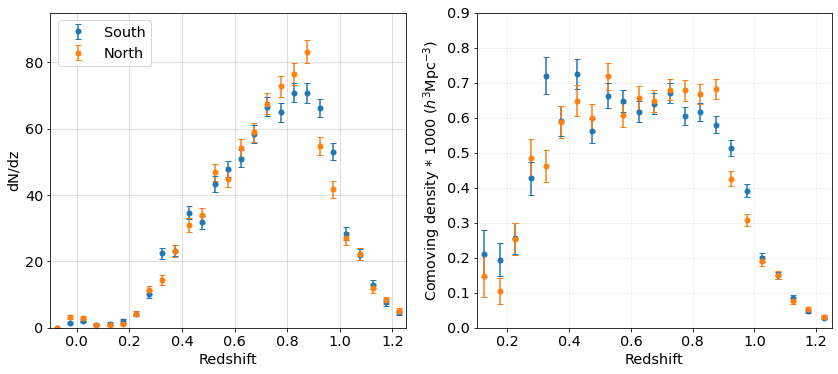

In [32]:
bins = np.arange(-0.1, 1.45, 0.05)
bin_centers = (bins[1:]+bins[:-1])/2

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    counts_south, _ = np.histogram(zbest['Z'][lrg_sv3_south], bins=bins)
    frac_err_south = 1/np.sqrt(counts_south)  # Poisson error only
    counts_north, _ = np.histogram(zbest['Z'][lrg_sv3_north], bins=bins)
    frac_err_north = 1/np.sqrt(counts_north)  # Poisson error only
    frac_err_south[~np.isfinite(frac_err_south)] = 0
    frac_err_north[~np.isfinite(frac_err_north)] = 0
    
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].errorbar(bin_centers, counts_south/area_sv3_south, yerr=frac_err_south*counts_south/area_sv3_south, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='South')
axes[0].errorbar(bin_centers, counts_north/area_sv3_north, yerr=frac_err_north*counts_north/area_sv3_north, fmt='o', ms=5, color='C1', capsize=3, capthick=1, label='North')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].set_ylim(0, 95)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3_south], area=area_sv3_south, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.9], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=True)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3_north], area=area_sv3_north, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.9], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=True)
# plt.legend(loc='lower left')
plt.show()

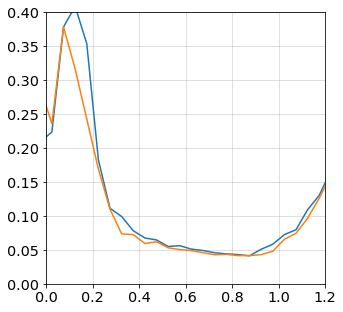

In [33]:
# Fractional uncertainty
plt.figure(figsize=(5, 5))
plt.plot(bin_centers, frac_err_north)
plt.plot(bin_centers, frac_err_south)
plt.axis([0, 1.2, 0, 0.4])
plt.grid(alpha=0.5)

-------------
## 600/sq.deg. version

In [19]:
# zfiber & sliding cut extension; 600 targets/sq.deg.

# mask_north = zbest['PHOTSYS']=='N'
# mask_south = zbest['PHOTSYS']=='S'

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.07) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.17) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.39
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.3) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.13)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag - zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.72)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.05) * 1.83 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.14) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.49
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag - rmag > 1.34) & ( (gmag - rmag) > -1.55 * (rmag - w1mag) + 3.23)
mask_lowz |= (rmag - w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g < 18)
lrg_mask &= (~mask_bright)

lrg_sv3_north = lrg_mask.copy()

lrg_sv3 = lrg_sv3_south | lrg_sv3_north
print(np.sum(lrg_sv3))

9103


In [20]:
lrg_sv3_600 = lrg_sv3.copy()
lrg_sv3_south_600 = lrg_sv3_south.copy()
lrg_sv3_north_600 = lrg_sv3_north.copy()

In [21]:
print(np.sum(lrg_sv3_south)/area_sv3_south)
print(np.sum(lrg_sv3_north)/area_sv3_north)

596.1905482987657
594.3456039998949


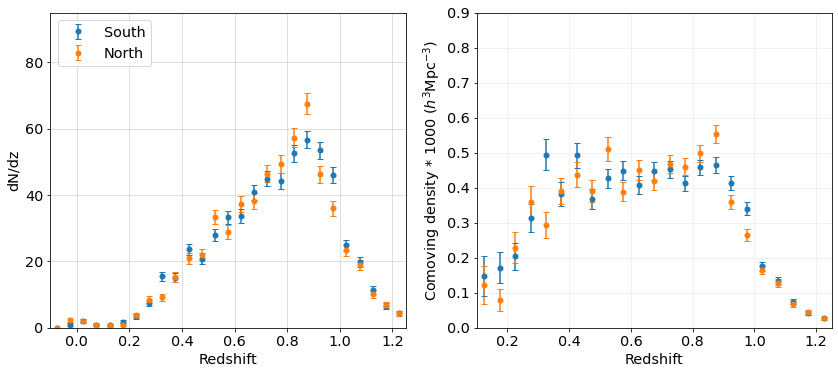

In [22]:
bins = np.arange(-0.1, 1.45, 0.05)
bin_centers = (bins[1:]+bins[:-1])/2

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    counts_south, _ = np.histogram(zbest['Z'][lrg_sv3_south], bins=bins)
    frac_err_south = 1/np.sqrt(counts_south)  # Poisson error only
    counts_north, _ = np.histogram(zbest['Z'][lrg_sv3_north], bins=bins)
    frac_err_north = 1/np.sqrt(counts_north)  # Poisson error only
    frac_err_south[~np.isfinite(frac_err_south)] = 0
    frac_err_north[~np.isfinite(frac_err_north)] = 0
    
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].errorbar(bin_centers, counts_south/area_sv3_south, yerr=frac_err_south*counts_south/area_sv3_south, fmt='o', ms=5, color='C0', capsize=3, capthick=1, label='South')
axes[0].errorbar(bin_centers, counts_north/area_sv3_north, yerr=frac_err_north*counts_north/area_sv3_north, fmt='o', ms=5, color='C1', capsize=3, capthick=1, label='North')
axes[0].legend(loc='upper left')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].set_ylim(0, 95)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3_south], area=area_sv3_south, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.9], xlabel='Redshift', show=False, lw=1.5, color='C0', errorbar=True)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_sv3_north], area=area_sv3_north, zmin=0.1, zmax=1.45, dz=0.05, axis=[0.1, 1.25, 0, 0.9], xlabel='Redshift', show=False, lw=1.5, color='C1', errorbar=True)
# plt.legend(loc='lower left')
plt.show()

In [23]:
sys.path.append(os.path.expanduser('/git/desi-lrg-selection'))
from modules import comoving_density

In [24]:
lrg_sv3_south_600 = lrg_sv3_south.copy()

In [25]:
bins = np.round(np.arange(0.2, 1.4, 0.05), 2)

# surface density
counts = np.histogram(zbest['Z'][lrg_sv3_south_800], bins=bins)[0]
surf_density_800 = np.round(counts/area_sv3_south, 1)
counts = np.histogram(zbest['Z'][lrg_sv3_south_600], bins=bins)[0]
surf_density_600 = np.round(counts/area_sv3_south, 1)

t = Table()
t['zmin'] = bins[:-1]
t['zmax'] = bins[1:]
t['N_z_800'] = surf_density_800
t['N_z_600'] = surf_density_600
# t['comoving_density'] = comov_density
t.write('data/sv3_lrg_dndz_denali.txt', format='ascii.commented_header', 
       formats={'zmin':'%4.2f', 'zmax':'%4.2f', 'N_z_800':'%.10g', 'N_z_600':'%.10g'},
       overwrite=False)
print(np.sum(t['N_z_800']))
print(np.sum(t['N_z_600']))
t

798.8000000000001
588.9


zmin,zmax,N_z_800,N_z_600
float64,float64,float64,float64
0.2,0.25,4.3,3.4
0.25,0.3,10.1,7.4
0.3,0.35,22.5,15.5
0.35,0.4,23.3,15.1
0.4,0.45,34.7,23.6
0.45,0.5,31.8,20.8
0.5,0.55,43.3,27.9
0.55,0.6,48.0,33.2
0.6,0.65,51.0,33.7


In [35]:
print('800/sqdeg:')
mask = lrg_sv3_800 & (zbest['Z']<0.3)
print('z<0.3:', np.sum(mask)/area_sv3)
mask = lrg_sv3_800 & (zbest['Z']>1)
print('z>1.0:', np.sum(mask)/area_sv3)
print()

print('600/sqdeg:')
mask = lrg_sv3_600 & (zbest['Z']<0.3)
print('z<0.3:', np.sum(mask)/area_sv3)
mask = lrg_sv3_600 & (zbest['Z']>1)
print('z>1.0:', np.sum(mask)/area_sv3)

800/sqdeg:
z<0.3: 23.347818772143196
z>1.0: 79.13406362547134

600/sqdeg:
z<0.3: 18.24661467066653
z>1.0: 68.80085531735195
